In [1]:
#Importing libraries 

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Importing stock data through API

re_df = yf.download(
    tickers = "RELIANCE.NS",
    start = "2000-01-01",
    end = "2026-04-01",
    interval = "1d",
    progress = False)
re_df = re_df.reset_index()
re_df["ticker"] = "RELIANCE.NS"
re_df = re_df[["Date", "ticker", "Open", "High","Low", "Close", "Volume"]]
re_df.columns = ["date", "ticker", "open", "high","low", "close", "volume"]

In [3]:
#EDA part

re_df.shape
re_df.isnull().sum()
re_df["date"] = pd.to_datetime(re_df["date"])
if re_df["date"].dt.tz is not None:
    re_df["date"] = re_df["date"].dt.tz.localize(None)

In [4]:
#start to make pipeline for to connect postgres to to python 

db_user = "postgres"
db_pass = "kuldip2611" #Here is sample password use your password for connection
db_host = "localhost"
db_port = "5432"
db_name = "reliance_price"

from sqlalchemy import create_engine, text
connection_string = (f"postgresql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}")
engine = create_engine(connection_string,pool_pre_ping=True)
try:
    with engine.connect() as ec:
        print("Connected successfully!!")
except Exception as ex:
    print(f"Not connected!{ex}")

Connected successfully!!


In [5]:
#Run only for one time otherwise your data would be duplicated

# rows_inserted = re_df.to_sql(
#     name = "price",
#     con = engine,
#     if_exists = "append",
#     index = False,
#     method = "multi",
#     chunksize = 500
# )
# print(f"Rows inserted: {rows_inserted}")

In [6]:
#Importing data through sql data-server

df = pd.read_sql(
    """
    select * from price
    order by date asc
    """,
    con = engine,
    parse_dates = ["date"]
)
df.shape
df.drop(columns = "id",inplace = True)

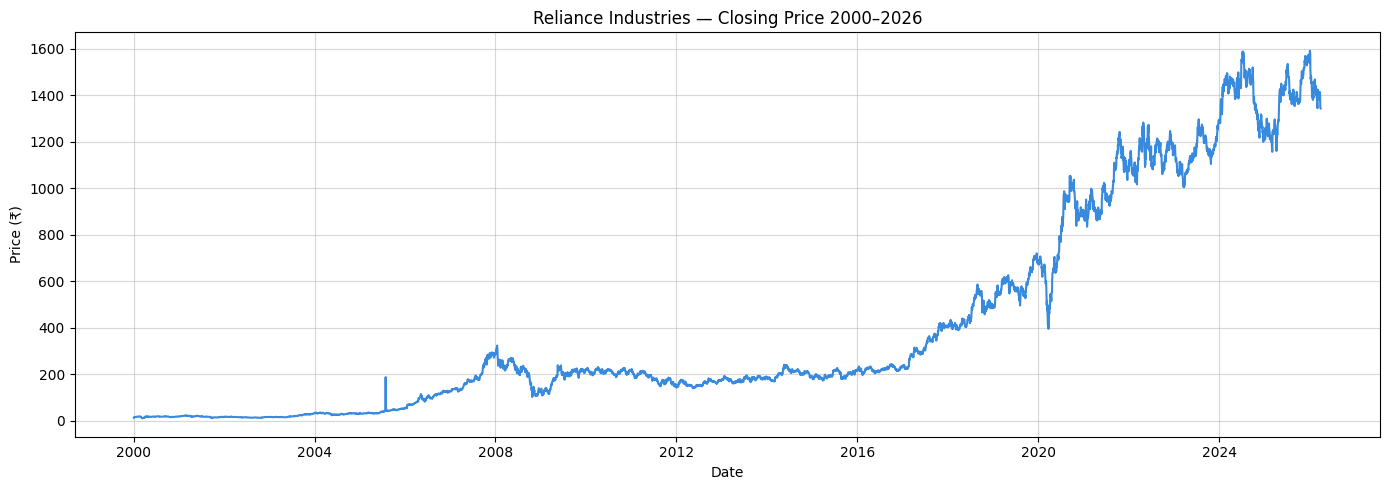

In [7]:
#Plot the stock price

plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['close'], color='#378ADD', linewidth=1.5)
plt.title('Reliance Industries — Closing Price 2000–2026')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
#Make the model -->PROPHET

In [9]:
#Spiltting data fot prophet

In [10]:
prophet_data = df[["date","close"]].rename(columns= {"date":"ds","close":"y"})
prophet_train = prophet_data[prophet_data["ds"]<="2024-01-01"]
prophet_test = prophet_data[prophet_data["ds"] > "2024-01-01"]

In [11]:
from prophet import Prophet #Importing prophet

In [12]:
#Trained prophet model 

model_pro = Prophet()
model_pro.fit(prophet_train)
future = model_pro.make_future_dataframe(periods = len(prophet_data) + 30 , freq = "B")
forecast = model_pro.predict(future)
forecast_test = forecast[forecast["ds"].isin(prophet_test["ds"])]
result = prophet_test[["ds","y"]].merge(forecast_test[["ds","yhat"]],left_on= "ds",right_on="ds")
result.head()

18:56:10 - cmdstanpy - INFO - Chain [1] start processing
18:56:15 - cmdstanpy - INFO - Chain [1] done processing


,ds,y,yhat
0,2024-01-02,1296.2559,1321.857475
1,2024-01-03,1282.1602,1322.235832
2,2024-01-04,1288.7860,1323.438104
3,2024-01-05,1294.2705,1322.934682
4,2024-01-08,1284.1704,1325.719389


In [13]:
import numpy as np
from sklearn.metrics import *
import matplotlib.pyplot as plt
import seaborn as sns

RMSE_Prophet = np.sqrt(mean_squared_error(result["y"],result["yhat"]))
R2_Prophet = r2_score(result["y"],result["yhat"])
MAPE_Prophet = np.mean(np.abs((result["y"] - result["yhat"])) / result["y"]) * 100

print(f"RMSE score : ₹{RMSE_Prophet}")
print(f"R2 score : {R2_Prophet}")
print(f"RAPE score : {MAPE_Prophet}")

RMSE score : ₹162.25089107680745
R2 score : -1.7316007604801684
RAPE score : 10.472602842619004


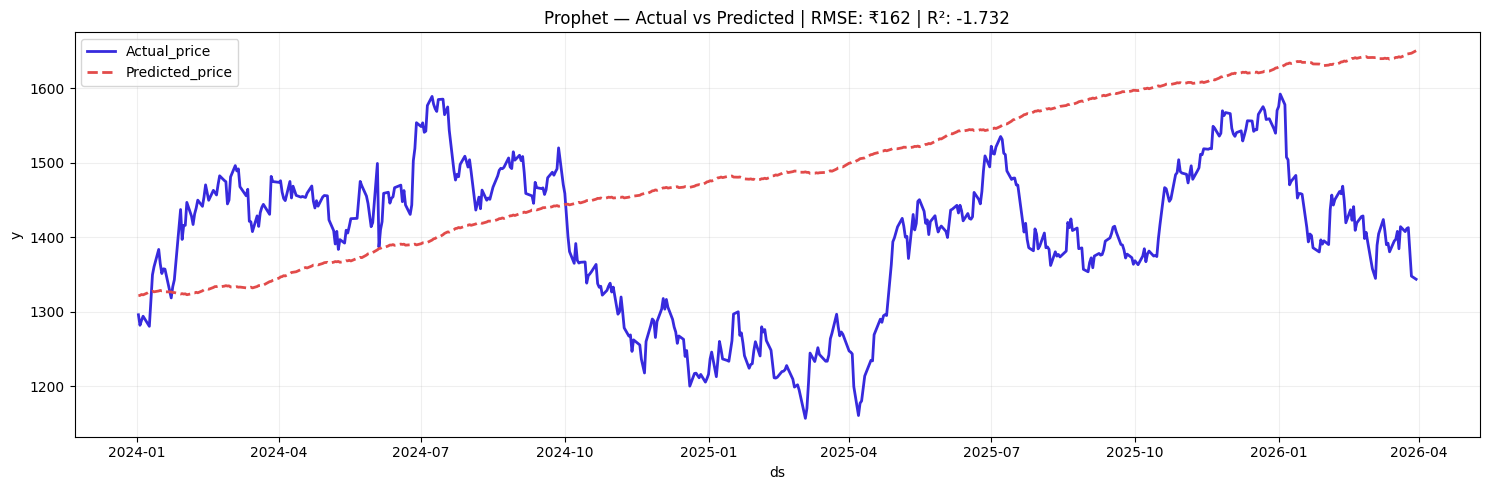

In [14]:
#Plot prophet prediction vs actual price prediction

plt.figure(figsize=(15,5))
sns.lineplot(x=result["ds"],y=result["y"],label="Actual_price",color="#372ADD",linewidth=2)
sns.lineplot(x=result["ds"],y=result["yhat"],label="Predicted_price",color="#E24B4A",linewidth=2,linestyle="--")
plt.title(f'Prophet — Actual vs Predicted | RMSE: ₹{RMSE_Prophet:.0f} | R²: {R2_Prophet:.3f}')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout() 
plt.show()

In [15]:
#Make the model using --> XGBOOST

In [16]:
#Feature engineering

In [17]:
#Make the copy of the original 

df_model = df[["date","close","volume"]].copy()
df_model = df_model.sort_values("date").reset_index(drop = True)
df_model.head()

,date,close,volume
0,2000-01-03,13.2444,62409578
1,2000-01-04,14.3047,132872110
2,2000-01-05,14.8651,375789847
3,2000-01-06,15.4886,219621124
4,2000-01-07,16.5516,278281260


In [18]:
#  1--> Adding past day changes
df_model["lag_1"] = df_model["close"].shift(1)
df_model["lag_5"] = df_model["close"].shift(5)
df_model["lag_10"] = df_model["close"].shift(10)
df_model["lag_21"] = df_model["close"].shift(21)

# 2 --> Moving avarage
df_model["ma_7"] = df_model["close"].rolling(7).mean()
df_model["ma_21"] = df_model["close"].rolling(21).mean()
df_model["ma_50"] = df_model["close"].rolling(50).mean()

# 3--> Market volatile
df_model["volatile"] = df_model["close"].rolling(14).std()

# 4--> pct changes
df_model["daily_return"] = df_model["close"].pct_change()
df_model["weakly_return"] = df_model["close"].pct_change(5)

# 5--> Momentum
delta = df["close"].diff()
gain = delta.clip(lower=0)
loss = (-delta).clip(lower=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = (avg_gain)/(avg_loss + 1e-9)
df_model["RSI"] = 100 - (100/(1 + rs))

# 6 --> price vs average moving price --> >1 up-trend , <1 down-trend
df_model["price vs ma_7"] = df_model["close"]/(df_model["ma_7"] + 1e-9)
df_model["price vs ma_21"] = df_model["close"]/(df_model["ma_21"] + 1e-9)
df_model["price vs ma_50"] = df_model["close"]/(df_model["ma_50"] + 1e-9)

# 7 --> volume
df_model['volume_MA7']   = df_model['volume'].rolling(7).mean()
df_model['volume_ratio'] = df_model['volume'] / (df_model['volume_MA7'] + 1)

# 8 --> target column
df_model['target'] = df_model['close'].pct_change().shift(-1)

# 9--> remove NaN rows
df_model = df_model.dropna().reset_index(drop=True)

print(f"Rows: {len(df_model)}, Features: {df_model.shape[1]-3}")
print(df_model.head(5))

Rows: 6495, Features: 17
        date    close     volume    lag_1    lag_5   lag_10   lag_21  \
0 2000-03-10  11.4106   92389443  12.1710  14.1258  17.2909  18.7195   
1 2000-03-13  10.6923  150763063  11.4106  13.3628  17.5277  19.1168   
2 2000-03-14  11.5343  141532996  10.6923  12.7498  16.3569  18.5274   
3 2000-03-15  12.4577   79982280  11.5343  12.2578  16.6700  18.1196   
4 2000-03-16  12.3578  147946692  12.4577  12.1710  15.3518  18.3196   

        ma_7      ma_21      ma_50  volatile  daily_return  weakly_return  \
0  13.061371  16.250376  16.552666  2.364813     -0.062476      -0.192216   
1  12.395729  15.849210  16.501624  2.527449     -0.062950      -0.199846   
2  12.025514  15.516205  16.446216  2.526350      0.078748      -0.095335   
3  11.896214  15.246590  16.398068  2.352709      0.080057       0.016308   
4  11.840214  14.962695  16.335452  2.159925     -0.008019       0.015348   

         RSI  price vs ma_7  price vs ma_21  price vs ma_50    volume_MA7  \
0 

In [19]:
#Model building 
train = df_model[df_model['date'] <= '2024-12-31']
test  = df_model[df_model['date'] >  '2024-12-31']


# Define features — all columns except date, close (raw), target
FEATURES = [col for col in df_model.columns
            if col not in ['date', 'close', 'target']]
TARGET = 'target'
print(f"\nFeatures used ({len(FEATURES)}): {FEATURES}")

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

# ── TRAIN XGBOOST 
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators     = 1000,  
    learning_rate    = 0.03,  
    max_depth        = 5,      
    subsample        = 0.8,
    colsample_bytree = 0.8,
    early_stopping_rounds = 50, 
    random_state     = 42,
    verbosity        = 0
)

#Split on validationn 
val_size = int(len(X_train)*0.2)
x_val = X_train[-val_size:]
y_val = y_train[-val_size:]
x_train_real = X_train[:-val_size]
y_train_real = y_train[:-val_size]


model_xgb.fit(
    x_train_real, y_train_real,
    eval_set  = [(x_val, y_val)],
    verbose   = False
)

# ── EVALUATE
y_pred = model_xgb.predict(X_test)

RMSE_XGB = np.sqrt(mean_squared_error(y_test, y_pred))
R2_XGB   = r2_score(y_test, y_pred)
MAE_XGB = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

print(f"\nXGBoost Results:")
print(f"  RMSE : ₹{RMSE_XGB:.2f}  (avg prediction error)")
print(f"  R²   : {R2_XGB:.4f}    (1.0 = perfect)")
print(f"  MAPE : {MAE_XGB:.2f}%   (average % error)") # But ir may misleading 


Features used (17): ['volume', 'lag_1', 'lag_5', 'lag_10', 'lag_21', 'ma_7', 'ma_21', 'ma_50', 'volatile', 'daily_return', 'weakly_return', 'RSI', 'price vs ma_7', 'price vs ma_21', 'price vs ma_50', 'volume_MA7', 'volume_ratio']

XGBoost Results:
  RMSE : ₹0.01  (avg prediction error)
  R²   : -0.0042    (1.0 = perfect)
  MAPE : inf%   (average % error)


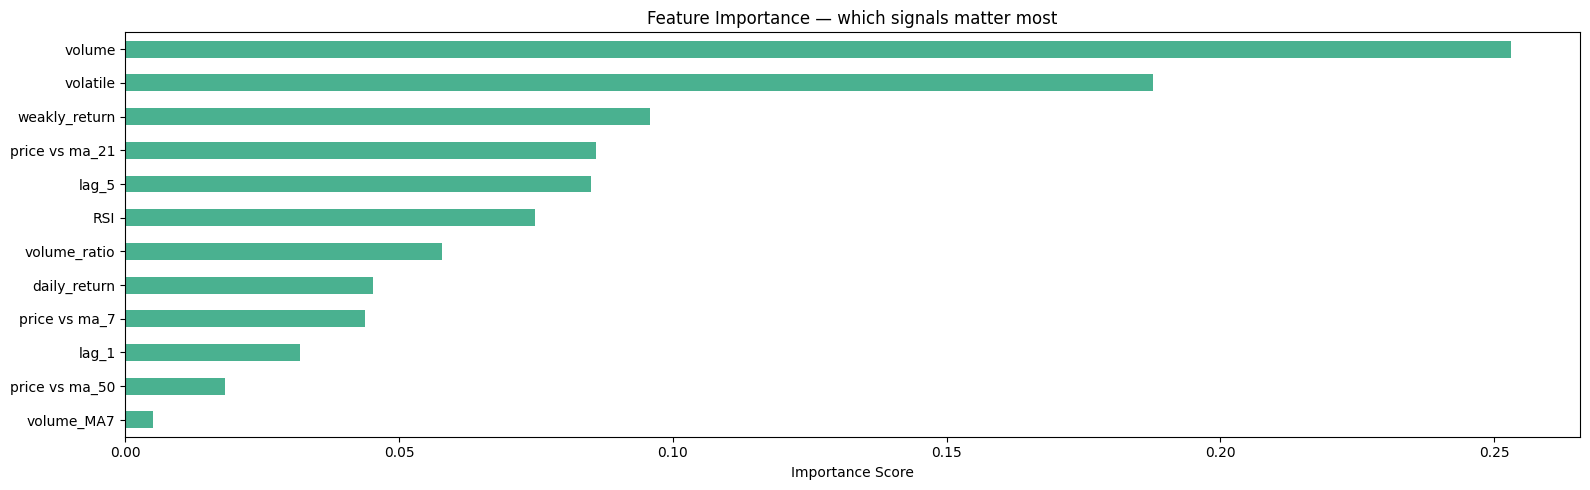

In [20]:
#Plotting graph 

fig, ax = plt.subplots(figsize=(16, 5))

feat_imp = pd.Series(
    model_xgb.feature_importances_,
    index=FEATURES
).sort_values(ascending=True).tail(12)   # top 12 features

# plot  - Feature Importance 
feat_imp.plot(kind='barh', ax=ax, color='#1D9E75', alpha=0.8)
ax.set_title('Feature Importance — which signals matter most')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [23]:
# Remove unnecessary feature 

fea_imp = pd.Series(
    model_xgb.feature_importances_,
    index = FEATURES
).sort_values(ascending= False)

print("\nAll feature list with their importance leval")
print(f"\n {(fea_imp.round(4)*100)} ")

thresold = 0.01 # Remove which have < 0.1% importance

good_feature = fea_imp[fea_imp >= thresold].index.tolist()
bad_feature = fea_imp[fea_imp < thresold].index.tolist()

print(f"Good feature that we take in next model bulding : {good_feature} \n Total feature that we take = {len(good_feature)}")
print(f"bad feature that we not take in next model bulding : {bad_feature} \n Total feature that we not take = {len(bad_feature)}")


All feature list with their importance leval

 volume            25.299999
volatile          18.770000
weakly_return      9.590000
price vs ma_21     8.600000
lag_5              8.510000
RSI                7.480000
volume_ratio       5.780000
daily_return       4.520000
price vs ma_7      4.390000
lag_1              3.190000
price vs ma_50     1.820000
volume_MA7         0.500000
lag_10             0.390000
ma_7               0.390000
ma_21              0.310000
ma_50              0.240000
lag_21             0.220000
dtype: float32 
Good feature that we take in next model bulding : ['volume', 'volatile', 'weakly_return', 'price vs ma_21', 'lag_5', 'RSI', 'volume_ratio', 'daily_return', 'price vs ma_7', 'lag_1', 'price vs ma_50'] 
 Total feature that we take = 11
bad feature that we not take in next model bulding : ['volume_MA7', 'lag_10', 'ma_7', 'ma_21', 'ma_50', 'lag_21'] 
 Total feature that we not take = 6


In [24]:
# Re-train on xgbooost
x_train_slim = train[good_feature]
x_test_slim = test[good_feature]

model_slim = XGBRegressor(
    n_estimators     = 1000,
    learning_rate    = 0.03,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    early_stopping_rounds = 50,
    random_state     = 42,
    verbosity        = 0
)
model_slim.fit(x_train_slim, y_train,
               eval_set=[(x_test_slim, y_test)], verbose=False)
y_pred_slim = model_slim.predict(x_test_slim)

RMSE_slim = np.sqrt(mean_squared_error(y_test, y_pred_slim))
R2_slim   = r2_score(y_test, y_pred_slim)
MAE_slim = np.mean(np.abs((y_test.values - y_pred_slim) / y_test.values)) * 100

baseline_pred = np.zeros_like(y_test)
baseline_acc = accuracy_score((y_test>0),(baseline_pred > 0))

print(f"\n── Before vs After dropping low-importance features ──")
print(f"{'Metric':<10} {'Before':>10} {'After':>10} {'Better?':>10}")
print("-"*42)
print(f"{'RMSE':<10}   ₹{RMSE_XGB:>7.5f}   ₹{RMSE_slim:>7.5f} {('✓' if RMSE_slim < RMSE_XGB else '✗'):>10}")
print(f"{'R²':<10} {round(R2_XGB,4):>10} {round(R2_slim,4):>10} {('✓' if R2_slim > R2_XGB else '✗'):>10}")
print(f"{'MAPE':<10} {str(round(MAE_XGB,2))+'%':>10} {str(round(MAE_slim,2))+'%':>10} {('✓' if MAE_slim < MAE_XGB else '✗'):>10}")
print(f"BASE_LINE  {baseline_acc}")


── Before vs After dropping low-importance features ──
Metric         Before      After    Better?
------------------------------------------
RMSE         ₹0.01298   ₹0.01296          ✓
R²            -0.0042    -0.0016          ✓
MAPE             inf%       inf%          ✗
BASE_LINE  0.4935064935064935


In [25]:
#Hyperperameter tuning

import sys
!{sys.executable} -m pip install optuna --quiet
import optuna
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

tscv = TimeSeriesSplit(n_splits=5)
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 2),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.1, 5),
        'random_state'     : 42,
        'verbosity'        : 0
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(
        model, x_train_slim, y_train,
        cv      = tscv,
        scoring = 'neg_root_mean_squared_error',
        n_jobs  = -1
    )
    return -scores.mean()

study = optuna.create_study(direction='minimize')  # minimise RMSE
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✓ Optuna finished!")
print(f"Best CV RMSE: ₹{study.best_value:.2f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k:<22}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


✓ Optuna finished!
Best CV RMSE: ₹0.04
Best params:
  n_estimators          : 1046
  learning_rate         : 0.08167533461103321
  max_depth             : 8
  subsample             : 0.5907785929029493
  colsample_bytree      : 0.6560307305116632
  min_child_weight      : 2
  gamma                 : 1.0279638436848824
  reg_alpha             : 0.747464306092151
  reg_lambda            : 2.6797649516534485


In [26]:
# Use the best params Optuna found — train on your actual split

best_params = study.best_params
best_params['random_state'] = 42
best_params['verbosity']    = 0

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model_tuned = XGBRegressor(**best_params)
model_tuned.fit(x_train_slim, y_train)

y_pred_tuned = model_tuned.predict(x_test_slim)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned   = r2_score(y_test, y_pred_tuned)
mape_tuned = np.mean(np.abs((y_test.values - y_pred_tuned) / y_test.values)) * 100

print(f"Tuned XGBoost on actual test set:")
print(f"  RMSE : ₹{rmse_tuned:.2f}")
print(f"  R²   : {r2_tuned:.4f}")


# Compare with original
print(f"\nOriginal XGBoost: RMSE=₹{RMSE_XGB:.4f}, R²={R2_XGB:.4f}")
winner = "Tuned" if rmse_tuned < RMSE_XGB else "Original"
print(f"Better model: {winner}")

Tuned XGBoost on actual test set:
  RMSE : ₹0.01
  R²   : -0.0062

Original XGBoost: RMSE=₹0.0130, R²=-0.0042
Better model: Original


In [27]:
# Now make the DL model

In [28]:
#importing library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler

In [29]:
#Importing data from sql database

df = pd.read_sql(
    """
    select date,close
    from price
    order by date ASC
    """,
    con = engine,
    parse_dates= ["date"]
)
df.shape

(6545, 2)

In [30]:
#Creating sequences

#make the function for it
def create_sequence(data,window):
    x,y = [],[]

    for i in range(window,len(data)):
        x.append(data[i-window:i,0])
        y.append(data[i,0])

    x = np.array(x)
    y = np.array(y)

    x = x.reshape(x.shape[0],x.shape[1],1)
    
    return x,y
    
#Data splitting and scaling 

window = 60
split = "2024-12-31"

train_df = df[df["date"] <= split]
test_df = df[df["date"] > split]

scaler = MinMaxScaler(feature_range=(0,1))

train_price = train_df["close"].values.reshape(-1,1)
test_price = test_df["close"].values.reshape(-1,1)

train_scaled = scaler.fit_transform(train_price)
test_scaled = scaler.transform(test_price)

#create sequence data

x_train,y_train = create_sequence(train_scaled,window)
combined = np.concatenate([train_scaled[-window:],test_scaled],axis=0)
x_test,y_test = create_sequence(combined,window)

val_size = int(len(x_train)*0.2)
x_train_real = x_train[:-val_size]
y_train_real = y_train[:-val_size]
x_val = x_train[-val_size:]
y_val = y_train[-val_size:]

print(f"\nX_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test  shape: {x_test.shape}")
print(f"y_test  shape: {y_test.shape}")
print(f"\nEach X sample: {window} timesteps × 1 feature")
print("Shape means: (samples, timesteps, features)")


X_train shape: (6176, 60, 1)
y_train shape: (6176,)
X_test  shape: (309, 60, 1)
y_test  shape: (309,)

Each X sample: 60 timesteps × 1 feature
Shape means: (samples, timesteps, features)


In [31]:
#Model building part

window = 60
tf.random.set_seed(42)


model = keras.Sequential()

model.add(layers.LSTM(units = 128 , return_sequences = True , input_shape = (window,1)))
model.add(layers.Dropout(0.35)) 
model.add(layers.LSTM(units = 64 , return_sequences = True ))
model.add(layers.Dropout(0.3)) 
model.add(layers.LSTM(units = 32 , return_sequences = False ))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(16,activation="relu"))
model.add(layers.Dense(1))

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    loss = "mse",
    metrics = ["mae"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 128,929 (503.63 KB)

 Trainable params: 128,929 (503.63 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
#Train the LSTM model fot price prediction

early_stop = EarlyStopping(
    monitor = "val_loss",
    patience = 25,
    restore_best_weights = True,
    verbose = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    patience = 10,
    factor = 0.5,
    min_lr = 1e-6,
    verbose = 1
)

history = model.fit(
    x_train_real,y_train_real,
    epochs = 100,
    batch_size = 32,
    validation_data = (x_val,y_val),
    callbacks = [early_stop,reduce_lr],
    verbose = 1
)

print("✓ Training complete!")

Epoch 1/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - loss: 0.0011 - mae: 0.0186 - val_loss: 0.0112 - val_mae: 0.0976 - learning_rate: 0.0010
Epoch 2/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - loss: 2.7300e-04 - mae: 0.0107 - val_loss: 0.0034 - val_mae: 0.0488 - learning_rate: 0.0010
Epoch 3/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - loss: 2.3187e-04 - mae: 0.0100 - val_loss: 9.6290e-04 - val_mae: 0.0247 - learning_rate: 0.0010
Epoch 4/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - loss: 1.9141e-04 - mae: 0.0090 - val_loss: 0.0018 - val_mae: 0.0348 - learning_rate: 0.0010
Epoch 5/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - loss: 1.7699e-04 - mae: 0.0089 - val_loss: 0.0031 - val_mae: 0.0479 - learning_rate: 0.0010
Epoch 6/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - loss: 1.6236e-04 - mae: 0.0084 - val_loss: 0.0090 - val_mae: 0.0874 - learning_rate: 0.0010
Epoch 7/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - loss: 1.4356e-04 - mae: 0.0080 - val_loss:

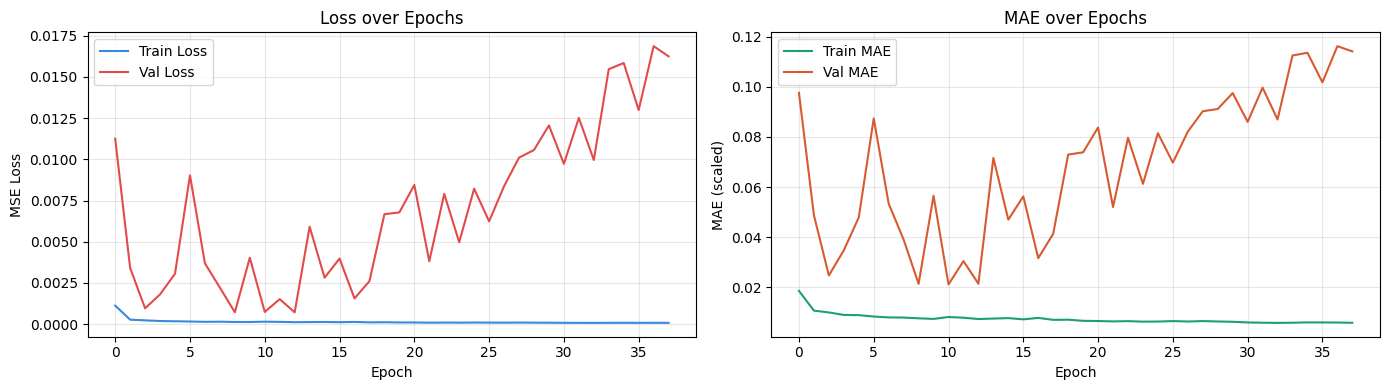

In [33]:
#Plot graphs 

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1 — Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='#378ADD')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#E24B4A')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot 2 — MAE
axes[1].plot(history.history['mae'],     label='Train MAE', color='#1D9E75')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#D85A30')
axes[1].set_title('MAE over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (scaled)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [34]:
y_pred_scaled = model.predict(x_test)


# ── INVERSE TRANSFORM — convert back to real ₹ prices ─────────

y_pred_real = scaler.inverse_transform(y_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
min_len = min(len(y_pred_real),len(y_test_real))

y_test_real = y_test_real[:min_len].flatten()
y_pred_real = y_pred_real[:min_len].flatten()

print(y_pred_real.shape)
print(y_test_real.shape)

# ── METRICS 
RMSE_LSTM = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
R2_LSTM   = r2_score(y_test_real, y_pred_real)
MAPE_LSTM = np.mean(
    np.abs((y_test_real - y_pred_real) / y_test_real)
) * 100

print("LSTM Results on Test Set:")
print(f"  RMSE : ₹{RMSE_LSTM:.2f}")
print(f"  R²   : {R2_LSTM:.2f}")
print(f"  MAPE : {MAPE_LSTM:.2f}%")


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
(309,)
(309,)
LSTM Results on Test Set:
  RMSE : ₹39.50
  R²   : 0.86
  MAPE : 2.28%


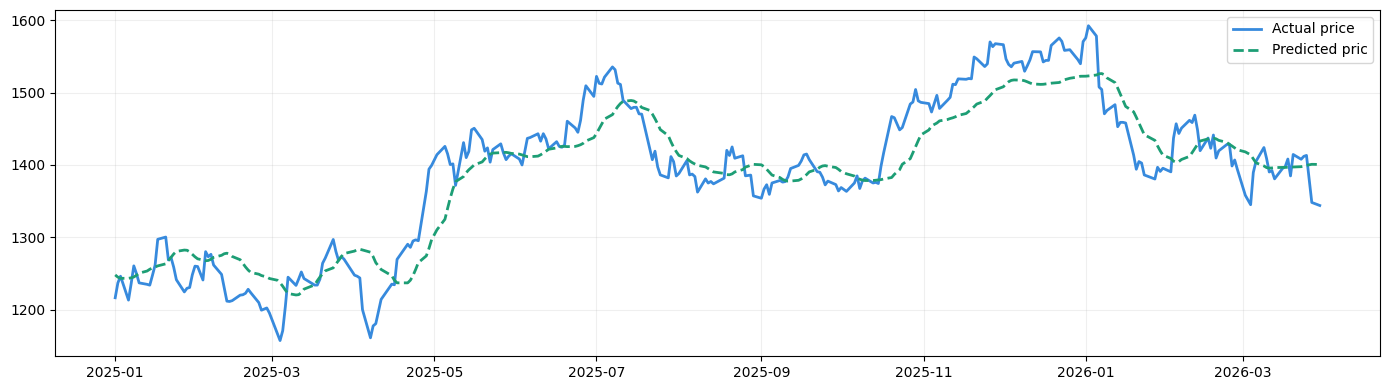

In [35]:
#Plot LSTM price prediction vs avtual prediction 


test_df = test_df["date"].values
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(test_df,y_test_real,label = "Actual price",color = "#378ADD" , linewidth = 2)
ax.plot(test_df,y_pred_real,label = "Predicted pric", color = "#1D9E75" , linewidth = 2 ,linestyle = "--" )
ax.legend()
ax.grid(alpha = 0.2)
plt.tight_layout()
plt.show()

In [36]:
# Comparision all three model side by side 

comparison = pd.DataFrame({
    "Model" : ["Prophet","XGBoost(tuned)","LSTM(DL)"],
    "RMSE(₹)" : [RMSE_Prophet,rmse_tuned,RMSE_LSTM],
    "R2" : [R2_Prophet,r2_tuned,R2_LSTM],
    "MAE(%)" : [R2_Prophet,mape_tuned,MAPE_LSTM],
})

print("="*65)
print("     FINAL MODEL COMPARISON — RELIANCE NSE STOCK")
print("="*65)
print(comparison.to_string(index=False))
print("="*65)
best = comparison.loc[comparison['R2'].idxmax(), 'Model']
print(f"\n✓ Best model: {best}")

     FINAL MODEL COMPARISON — RELIANCE NSE STOCK
         Model    RMSE(₹)        R2    MAE(%)
       Prophet 162.250891 -1.731601 -1.731601
XGBoost(tuned)   0.012989 -0.006235       inf
      LSTM(DL)  39.497054  0.855754  2.281849

✓ Best model: LSTM(DL)
